# 🔍 Crypto Protocol Risk Scoring : Notebook 1 : Collecte des données

**Objectif** : construire un dataset structuré de protocoles crypto (DeFi, CEX, bridges) avec leurs caractéristiques et un label `hacked` (0 = sain, 1 = piraté).  
Ce dataset sera exporté en Parquet et chargé dans le Notebook 2 pour l'entraînement du modèle ML.

> **Périmètre** : protocoles DeFi, CEX et bridges : toute plateforme crypto financière documentée par DefiLlama.

## Glossaire DeFi

| Terme | Définition |
|-------|----------|
| **TVL** (Total Value Locked) | Valeur totale des actifs déposés dans un protocole. Indicateur de popularité et de maturité. |
| **Hack / Exploit** | Attaque qui vole des fonds via une faille du smart contract, un flash loan, ou une manipulation de prix. |
| **Admin keys** | Clés privées qui permettent à une équipe de modifier un protocole sans vote. Risque de rug pull. |
| **Audit** | Vérification du code par une société spécialisée (Trail of Bits, OpenZeppelin...). Réduit (mais n'élimine pas) le risque. |
| **Rug pull** | L'équipe abandonne le projet et part avec les fonds. |
| **Flash loan** | Prêt instantané (dans une seule transaction) sans collatéral, souvent utilisé pour manipuler des prix. |
| **Liquidity pool** | Réserves de tokens déposées par des fournisseurs de liquidité (LP) pour permettre les échanges. |

## Choix architecturaux et arbitrages

### Sources retenues

| Source | Rôle | Justification |
|--------|------|---------------|
| **DefiLlama /protocols** | Base du dataset (features structurelles) | Couverture exhaustive (4800+ protocoles), API stable, features publiques vérifiables |
| **DefiLlama /hacks** | Labels (hacked/non-hacked) + contexte | Seule source structurée avec `defillamaId` pour un join fiable |
| **Rekt News** | Présence documentée dans le pipeline | Tags = noms de protocoles/blockchains/attaques : aucune valeur `'audited'`/`'unaudited'` sur 353 tags uniques (0/286 entrées). Maintenu pour traçabilité. |

### Sources explorées puis écartées

| Source | Raison de l'abandon |
|--------|---------------------|
| **Dune Analytics** | Couverture insuffisante sur le périmètre multi-protocoles (0.8%), matching fragile par nom avec DefiLlama, et ne résout pas le biais temporel (données on-chain = snapshot actuel) |
| **CertiK Skynet** | Scraping fragile, couverture incomplète à défendre pour un rendu de certification |
| **DeFiSafety** | Idem : pas d'API publique, scraping non pérenne |

### Biais temporel assumé

Les features DefiLlama sont des **snapshots 2026** pour des hacks de **2016-2025**.
Le modèle apprend le *profil structurel* des protocoles historiquement ciblés, pas une prédiction temporelle causale.

**Pourquoi ne pas corriger ce biais maintenant :**
L'API `/protocol/{slug}` permettrait de récupérer le TVL historique pour les protocoles hackés (TVL à T-30 avant le hack). Mais pour les 96.6% de protocoles non hackés, il n'existe pas de date d'incident de référence. Utiliser le TVL actuel pour les non-hackés et le TVL pré-hack pour les hackés introduirait un **biais asymétrique** entre les deux classes.
La solution (fenêtre glissante avec dates d'observation simulées) dépasse le scope de cette version.

### Ce que le modèle peut et ne peut pas faire

| Ce qu'il peut faire | Ce qu'il ne peut pas faire |
|---------|---------------|
| Classer les protocoles par profil de risque structurel | Prédire *quand* un hack va survenir |
| Identifier les caractéristiques récurrentes des protocoles hackés | Garantir qu'un protocole "safe" ne sera jamais hacké |
| Servir d'outil de screening pour une revue humaine (ranking top-k) | Remplacer un audit de sécurité |

## 0. Imports

In [27]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from bs4 import BeautifulSoup
from datetime import datetime, date
import json
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

TODAY = date.today()
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Date du jour : {TODAY.strftime("%d-%m-%Y")}')
print('Imports OK')

Date du jour : 17-03-2026
Imports OK


---
## 1. Labels : DefiLlama `/hacks` + Rekt News

Les labels (`hacked = 0 / 1`) sont la **variable cible** du modèle. Leur qualité conditionne tout le reste.

Deux sources complémentaires :
- **DefiLlama `/hacks`** (1A) : API gratuite, ~500 hacks documentés, champs riches (`technique`, `bridgeHack`, `targetType`)
- **Rekt News leaderboard** (1B) : exploré pour enrichissement du statut d'audit : 0 feature ML produite (voir section 1B)

### Pourquoi deux sources ?

DefiLlama couvre le volume (labels + features structurelles). Rekt News est présent dans
le pipeline pour une tentative d'enrichissement du statut d'audit via les tags du leaderboard.
Les tags ne contiennent pas les valeurs `'audited'`/`'unaudited'` (résultat : 0/286 matchs) :
`audit_status` est entièrement dérivé de `has_audit` DefiLlama. Ce n'est pas un signal indépendant.

### 1A. DefiLlama `/hacks` : source principale des labels

API gratuite, sans clé. Retourne tous les hacks DeFi documentés avec leurs métadonnées.

Champs disponibles :

| Champ | Description |
|-------|-------------|
| `name` | Nom du protocole hacké |
| `date` | Timestamp Unix de l'incident |
| `amount` | Montant perdu en USD |
| `chain` | Blockchain(s) concernée(s) |
| `technique` | Technique d'attaque (Flash loan, Compromised keys...) |
| `classification` | Catégorie de l'exploit |
| `bridgeHack` | Booléen : attaque sur un bridge cross-chain |
| `targetType` | Type de cible (DeFi Protocol, CEX, Bridge...) |
| `returnedFunds` | Montant récupéré (si applicable) |
| `defillamaId` | ID de jointure directe avec `/protocols` |

In [ ]:
# Source 1A : DefiLlama /hacks
print('Appel à DefiLlama /hacks...')

resp = requests.get('https://api.llama.fi/hacks', timeout=30)
resp.raise_for_status()
hacks_raw = resp.json()

df_hacks = pd.DataFrame(hacks_raw)

# Normalisation
df_hacks['hack_date']  = pd.to_datetime(df_hacks['date'], unit='s', errors='coerce')
df_hacks['loss_usd']   = pd.to_numeric(df_hacks['amount'], errors='coerce').fillna(0)
df_hacks['protocol']   = df_hacks['name'].str.strip()
df_hacks['hacked']     = 1

# Chaînes : liste → première chaîne principale
df_hacks['chain_hack'] = df_hacks['chain'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unknown'
)

# Fonds récupérés (nullable)
df_hacks['returned_funds'] = pd.to_numeric(df_hacks['returnedFunds'], errors='coerce').fillna(0)
df_hacks['net_loss_usd']   = df_hacks['loss_usd'] - df_hacks['returned_funds']

print(f'Hacks documentés  : {len(df_hacks)}')
print(f'Pertes totales    : ${df_hacks["loss_usd"].sum():,.0f}')
print(f'Fonds récupérés   : ${df_hacks["returned_funds"].sum():,.0f} ({df_hacks["returned_funds"].sum()/df_hacks["loss_usd"].sum():.1%})')
print(f'Période couverte  : {df_hacks["hack_date"].min().strftime("%d-%m-%Y")} → {df_hacks["hack_date"].max().strftime("%d-%m-%Y")}')
df_hacks[['protocol', 'hack_date', 'loss_usd', 'technique', 'bridgeHack', 'targetType', 'defillamaId']].head()

Appel à DefiLlama /hacks...
Hacks documentés  : 472
Pertes totales    : $15,853,250,999
Fonds récupérés   : $2,352,508,733 (14.8%)
Période couverte  : 17-06-2016 → 12-03-2026


,protocol,hack_date,loss_usd,technique,bridgeHack,targetType,defillamaId
0,Super Sushi Samurai,2024-03-22,"4,800,000.00",Infinite Mint and Dump,False,Gaming,NaN
1,Unizen,2024-03-08,"2,100,000.00",External Call Vulnerability,False,DeFi Protocol,"1,336.00"
2,AutoShark,2021-05-24,"745,000.00",Flashloan Incentive Rewards Exploit,False,DeFi Protocol,"1,074.00"
3,Siren,2021-09-03,"3,450,000.00",Reentrancy,False,DeFi Protocol,203.00
4,MangoFarmSol,2024-01-07,"2,000,000.00",Frontend Attack,False,DeFi Protocol,NaN


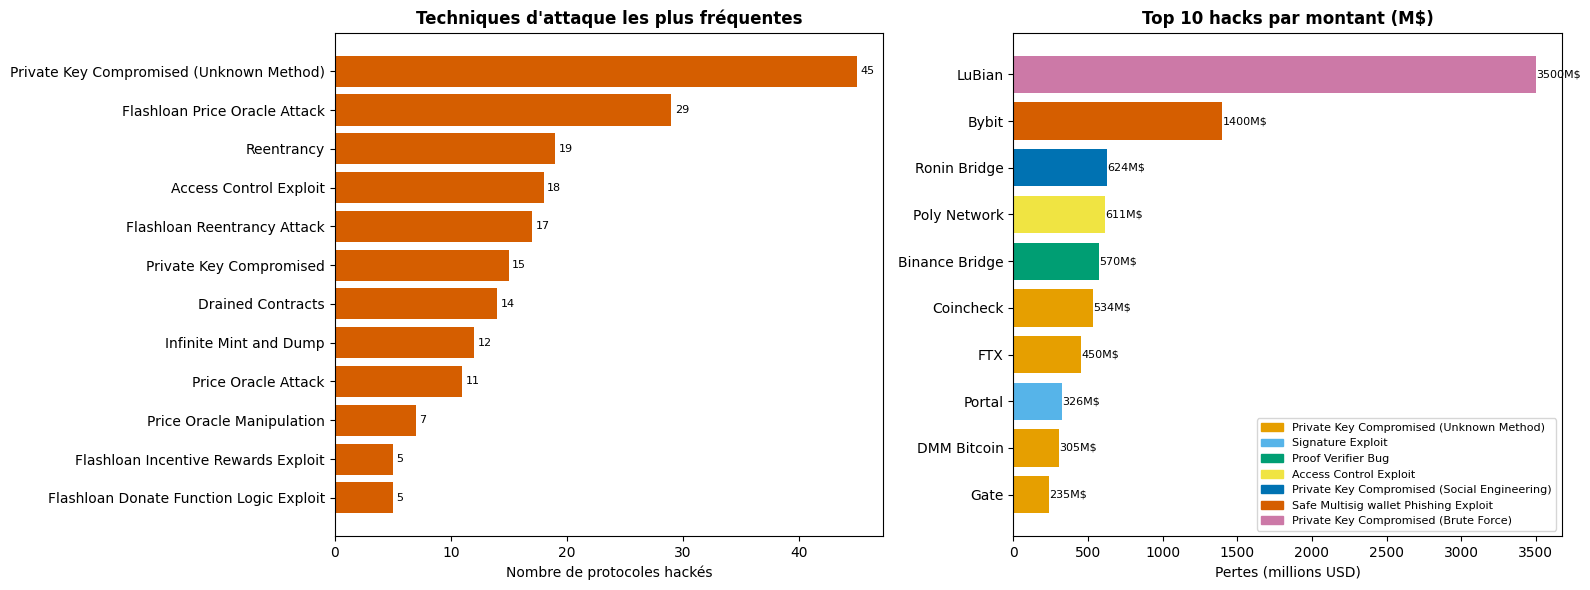

→ Top 3 techniques d'attaque :
   1. Private Key Compromised (Unknown Method) (45 cas sur 472)
   2. Flashloan Price Oracle Attack (29 cas sur 472)
   3. Reentrancy (19 cas sur 472)
→ Attaques sur bridges : 33 (7.0%) — souvent les plus coûteuses car montants concentrés
→ Top 3 pertes : Ronin Bridge, Bybit, LuBian
→ Ronin Network : 2 lignes dans les données — chaque ligne correspond à un incident distinct


In [ ]:
# Visualisation des hacks : techniques et top pertes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphe 1 : fréquence des techniques d'attaque ---
technique_counts = df_hacks['technique'].value_counts().head(12)
axes[0].barh(technique_counts.index[::-1], technique_counts.values[::-1], color='#D55E00')
axes[0].set_title("Techniques d'attaque les plus fréquentes", fontweight='bold')
axes[0].set_xlabel('Nombre de protocoles hackés')
for i, v in enumerate(technique_counts.values[::-1]):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=8)

# --- Graphe 2 : top 10 pertes par protocole, coloré par technique ---
top10 = df_hacks.nlargest(10, 'loss_usd').sort_values('loss_usd')
techniques_top = top10['technique'].unique()
# Palette Okabe-Ito (colorblind-safe, WCAG 2.1 §1.4.1)
OKABE_ITO = ['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7','#000000','#999999','#88CCEE']
palette = OKABE_ITO
color_map = {t: palette[i % len(palette)] for i, t in enumerate(techniques_top)}
colors = top10['technique'].map(color_map)

axes[1].barh(top10['protocol'], top10['loss_usd'] / 1e6, color=colors)
axes[1].set_title('Top 10 hacks par montant (M$)', fontweight='bold')
axes[1].set_xlabel('Pertes (millions USD)')

patches = [mpatches.Patch(color=color_map[t], label=t) for t in techniques_top]
axes[1].legend(handles=patches, loc='lower right', fontsize=8)
for i, (_, row) in enumerate(top10.iterrows()):
    axes[1].text(row['loss_usd'] / 1e6 + 2, i, f'{row["loss_usd"]/1e6:.0f}M$', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Prints dynamiques : top 3 techniques calculées depuis les données réelles
top3_techniques = technique_counts.head(3)
bridge_hacks    = df_hacks['bridgeHack'].sum()
bridge_pct      = bridge_hacks / len(df_hacks)
top3_protocols  = top10.tail(3)['protocol'].tolist()

print('→ Top 3 techniques d\'attaque :')
for i, (tech, count) in enumerate(top3_techniques.items(), 1):
    print(f'   {i}. {tech} ({count} cas sur {len(df_hacks)})')

print(f'→ Attaques sur bridges : {bridge_hacks} ({bridge_pct:.1%}) — souvent les plus coûteuses car montants concentrés')
print(f'→ Top 3 pertes : {", ".join(top3_protocols)}')

# Ronin peut apparaître plusieurs fois : chaque ligne = un incident distinct (normal)
ronin_count = df_hacks[df_hacks['protocol'].str.lower().str.contains('ronin', na=False)].shape[0]
if ronin_count > 1:
    print(f'→ Ronin Network : {ronin_count} lignes dans les données — chaque ligne correspond à un incident distinct')


### 1B. Rekt News leaderboard : Enrichissement tenté

DefiLlama `/hacks` ne fournit pas de statut d'audit structuré. Rekt News leaderboard a été
exploré comme source de tags `'audited'`/`'unaudited'` pour les protocoles hackés.

**Résultat** : les tags du leaderboard contiennent des noms de protocoles, blockchains et
types d'attaque (ex : `['Wormhole', 'Solana', 'REKT']`). Aucune valeur `'audited'` ou
`'unaudited'` n'existe dans les 353 tags uniques extraits.

`audit_status` sera entièrement dérivé de `has_audit` DefiLlama dans le merge (section 3).

In [ ]:
# Source 1B : Rekt News leaderboard (audit status)
print('Extraction du leaderboard Rekt News...')

USE_REKT = True

df_rekt_audit = pd.DataFrame()

if USE_REKT:
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp_rekt = requests.get('https://rekt.news/leaderboard/', headers=headers, timeout=15)
        resp_rekt.raise_for_status()
        soup = BeautifulSoup(resp_rekt.text, 'html.parser')

        # Le JSON est dans un tag <script id="__NEXT_DATA__">
        script_tag = soup.find('script', {'id': '__NEXT_DATA__'})
        if script_tag:
            next_data = json.loads(script_tag.string)
            # Naviguer dans la structure Next.js pour trouver les données du leaderboard
            leaderboard = (
                next_data
                .get('props', {})
                .get('pageProps', {})
                .get('leaderboard', [])
            )
            if leaderboard:
                df_rekt_audit = pd.DataFrame(leaderboard)
                # Normalisation des colonnes (noms peuvent varier)
                col_map = {c: c.lower().replace(' ', '_') for c in df_rekt_audit.columns}
                df_rekt_audit = df_rekt_audit.rename(columns=col_map)
                df_rekt_audit['protocol_key'] = df_rekt_audit.get(
                    'title', df_rekt_audit.iloc[:, 1]
                ).str.lower().str.strip().str.replace(r'\s*-\s*rekt$', '', regex=True)
                print(f'  ✅ {len(df_rekt_audit)} entrées Rekt — colonnes : {list(df_rekt_audit.columns)}')
            else:
                print('  Structure JSON Rekt modifiée — section USE_REKT désactivée')
                USE_REKT = False
        else:
            print('  Tag __NEXT_DATA__ absent — section USE_REKT désactivée')
            USE_REKT = False
    except Exception as e:
        print(f'  Erreur Rekt News : {e}')
        USE_REKT = False


# --- Tags Rekt News : tentative d'extraction du statut d'audit ---
# Résultat : les tags sont de la forme ['Wormhole', 'Solana', 'REKT'] noms de protocoles,
# blockchains et types d'attaque. Aucune valeur 'audited' ou 'unaudited' sur 353 tags uniques.
# 0/286 entrées exploitables. audit_status sera dérivé de has_audit DefiLlama (section 3).

if not USE_REKT or df_rekt_audit.empty:
    print('Rekt News non disponible — audit_status sera imputé depuis DefiLlama audit_links')
    df_rekt_audit = pd.DataFrame(columns=['protocol_key', 'audit_status'])

Extraction du leaderboard Rekt News...
  ✅ 286 entrées Rekt — colonnes : ['date', 'featured', 'title', 'rekt', 'tags', 'excerpt', 'banner', 'slug', 'protocol_key']


---
## 2. Source DefiLlama : Métadonnées des protocoles

**DefiLlama** offre une API REST **gratuite, sans clé** (au moment de l'exécution de ce notebook) avec des données sur tous les protocoles DeFi majeurs.

Endpoint principal : `https://api.llama.fi/protocols`

Pour chaque protocole on récupère :
- `tvl` : TVL actuel en USD
- `category` : type de protocole (DEX, Lending, Bridge...)
- `chains` : blockchains supportées
- `audit_links` : liens vers les audits
- `listedAt` : date de référencement (proxy de la date de lancement)


In [31]:
# Appel à l'API DefiLlama
print('Appel à DefiLlama API...')

response = requests.get('https://api.llama.fi/protocols', timeout=30)
response.raise_for_status()
protocols_raw = response.json()

print(f'Protocoles récupérés : {len(protocols_raw)}')
print('Exemple de champs disponibles :', list(protocols_raw[0].keys())[:15])

Appel à DefiLlama API...
Protocoles récupérés : 7202
Exemple de champs disponibles : ['id', 'name', 'address', 'symbol', 'url', 'description', 'chain', 'logo', 'audits', 'gecko_id', 'cmcId', 'category', 'chains', 'module', 'twitter']


In [32]:
# Extraction des champs utiles
# On ne modifie JAMAIS les données brutes : on travaille sur une copie structurée

def extract_protocol_features(p):
    """Extrait les features clés d'un protocole depuis la réponse DefiLlama."""
    return {
        'protocol':      p.get('name', '').strip(),
        'protocol_id':   str(p['id']) if p.get('id') is not None else None,  # clé de jointure avec /hacks
        'tvl':           p.get('tvl', 0) or 0,
        'category':      p.get('category', 'Unknown'),
        'chains':        p.get('chains', []),
        'chain_count':   len(p.get('chains', [])),
        'listed_at':     p.get('listedAt', None),      # timestamp UNIX
        'audit_links':   p.get('audit_links', []) or [],
        'audit_count':   len(p.get('audit_links', []) or []),
        'has_audit':     len(p.get('audit_links', []) or []) > 0,
        'twitter':       p.get('twitter', None),
        'mcap':          p.get('mcap', 0) or 0,
    }

llama_records = [extract_protocol_features(p) for p in protocols_raw]
df_llama = pd.DataFrame(llama_records)

# Conversion date de lancement
df_llama['launch_date'] = pd.to_datetime(df_llama['listed_at'], unit='s', errors='coerce')
df_llama['age_days'] = (pd.Timestamp.now() - df_llama['launch_date']).dt.days.clip(lower=0)

# Filtrer les protocoles sans TVL ni date (probablement inactifs)
df_llama = df_llama[(df_llama['tvl'] > 0) & (df_llama['age_days'] > 0)].copy()

print(f'Protocoles avec TVL et date valides : {len(df_llama)}')
print(f'TVL médian : ${df_llama["tvl"].median():,.0f}')
df_llama[['protocol', 'protocol_id', 'tvl', 'category', 'chain_count', 'audit_count', 'age_days']].head()


Protocoles avec TVL et date valides : 4870
TVL médian : $45,993


,protocol,protocol_id,tvl,category,chain_count,audit_count,age_days
0,Binance CEX,2269,"157,300,895,087.81",CEX,32,0,"1,221.00"
1,Aave V3,1599,"26,226,310,322.40",Lending,20,1,"1,446.00"
3,OKX,2272,"18,899,856,856.67",CEX,19,0,"1,221.00"
4,Bitfinex,2275,"17,577,249,303.01",CEX,20,0,"1,221.00"
5,Bybit,2286,"16,323,251,209.77",CEX,35,0,"1,217.00"


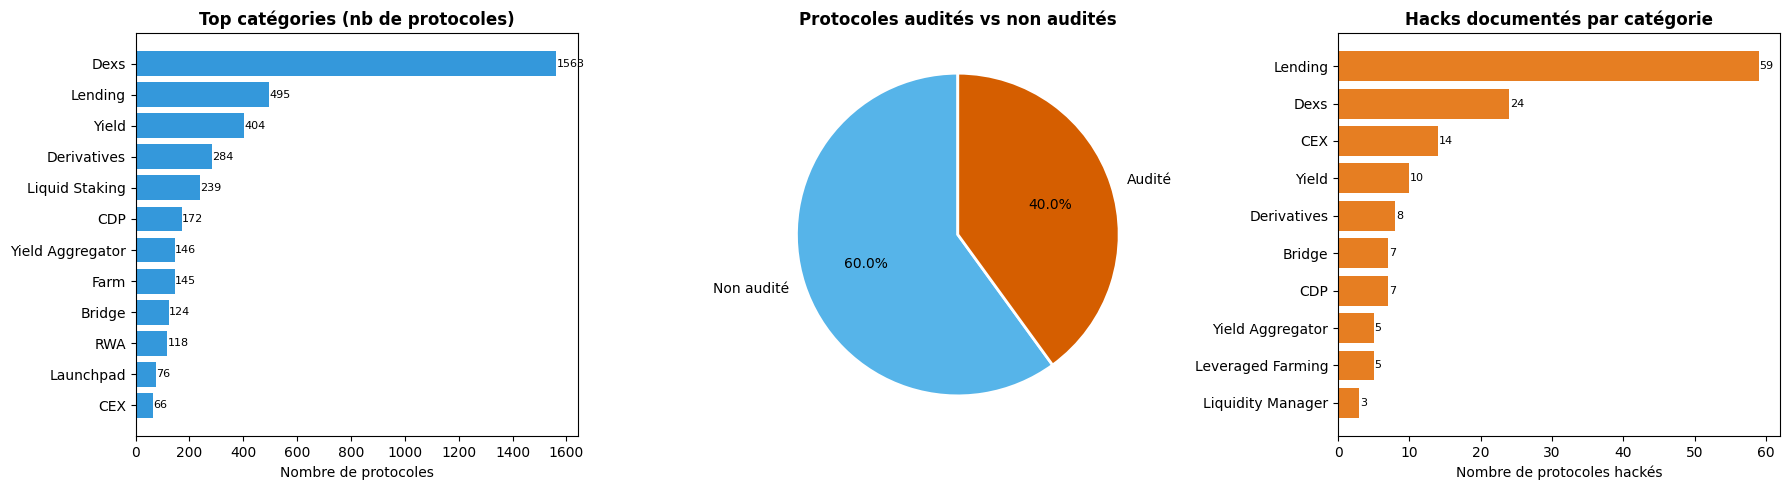

→ Dexs est la catégorie la plus représentée (1563 protocoles sur 4870).
→ Seulement 40.0% des protocoles ont été audités — la grande majorité n'a aucune revue de code externe.
→ Catégorie la plus ciblée : Lending (59 incidents documentés).
   Ce déséquilibre par catégorie sera capturé dans le modèle via les features is_dex, is_lending, is_bridge.


In [ ]:
# Exploration des protocoles DefiLlama
# Trois questions clés avant de construire le dataset :
# 1. Quelles catégories de protocoles sont les plus représentées ?
# 2. Quelle proportion a été auditée ?
# 3. Quelles catégories sont les plus ciblées par les hackers ?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Graphe 1 : top catégories par nombre de protocoles ---
# → comprendre la composition du dataset qu'on va construire
top_cats = df_llama['category'].value_counts().head(12)
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1], color='#3498db')
axes[0].set_title('Top catégories (nb de protocoles)', fontweight='bold')
axes[0].set_xlabel('Nombre de protocoles')
for i, v in enumerate(top_cats.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# --- Graphe 2 : distribution des audits ---
# → l'audit est une feature clé du modèle : on vérifie ici sa couverture réelle
audit_counts = df_llama['has_audit'].map({True: 'Audité', False: 'Non audité'}).value_counts()
colors_audit = ['#56B4E9', '#D55E00']  # Okabe-Ito
axes[1].pie(
    audit_counts.values,
    labels=audit_counts.index,
    autopct='%1.1f%%',
    colors=colors_audit,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Protocoles audités vs non audités', fontweight='bold')

# --- Graphe 3 : protocoles hackés par catégorie ---
# → montre quelles catégories sont les plus dangereuses (directement utile pour le risk scanner)
_hacks_key = df_hacks[['protocol']].copy()
_hacks_key['protocol_key'] = _hacks_key['protocol'].str.lower().str.strip()
_llama_key = df_llama[['protocol', 'category']].copy()
_llama_key['protocol_key'] = _llama_key['protocol'].str.lower().str.strip()
_hacks_cat = _hacks_key.merge(_llama_key[['protocol_key', 'category']], on='protocol_key', how='left')
hacks_by_cat = _hacks_cat['category'].value_counts().dropna().head(10)

axes[2].barh(hacks_by_cat.index[::-1], hacks_by_cat.values[::-1], color='#e67e22')
axes[2].set_title('Hacks documentés par catégorie', fontweight='bold')
axes[2].set_xlabel('Nombre de protocoles hackés')
for i, v in enumerate(hacks_by_cat.values[::-1]):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

most_hacked_cat   = hacks_by_cat.index[0]
most_hacked_count = hacks_by_cat.iloc[0]
audit_pct         = df_llama['has_audit'].mean()

print(f'→ {top_cats.index[0]} est la catégorie la plus représentée ({top_cats.iloc[0]} protocoles sur {len(df_llama)}).')
print(f'→ Seulement {audit_pct:.1%} des protocoles ont été audités — la grande majorité n\'a aucune revue de code externe.')
print(f'→ Catégorie la plus ciblée : {most_hacked_cat} ({most_hacked_count} incidents documentés).')
print(f'   Ce déséquilibre par catégorie sera capturé dans le modèle via les features is_dex, is_lending, is_bridge.')


---
## 3. Merge des datasets

On assemble les deux sources avec un framing explicite :
1. **Base de modélisation** : uniquement les protocoles DefiLlama encore présents au moment de l'extraction, avec `TVL > 0` et date de listing exploitable (`age_days > 0`).
2. **Labels** : DefiLlama `/hacks` fournit `472` hacks documentés, mais seuls les incidents qui retombent sur cette base active filtrée peuvent entrer dans le dataset final.
3. **Résultat** : le parquet final ne modélise donc pas "tous les hacks historiques", mais le risque au sein de l'univers de protocoles encore actifs / encore présents dans DefiLlama.
4. **`audit_status`** : dérivé de `has_audit` DefiLlama (Rekt News exploré, tags non exploitables)

> 💡 Tous les joins sont des **left joins** sur la base DefiLlama filtrée. Un hack absent de cette base active n'apparaît pas dans le dataset ML final.


In [ ]:
# Normalisation des clés de jointure
df_llama['protocol_key'] = df_llama['protocol'].str.lower().str.strip()
df_hacks['protocol_key'] = df_hacks['protocol'].str.lower().str.strip()

# defillamaId dans /hacks est un float (ex: 1336.0) => on normalise en string entier
df_hacks['defillamaId_str'] = df_hacks['defillamaId'].apply(
    lambda x: str(int(x)) if pd.notna(x) else None
)

# --- Join 1 : DefiLlama /protocols × /hacks ---
# Stratégie : protocol_id en priorité (jointure propre sur l'ID), nom normalisé en fallback

# Étape 1a : join via protocol_id (hacks qui ont un defillamaId connu)
hacks_with_id = df_hacks[df_hacks['defillamaId_str'].notna()].copy()
hacks_no_id   = df_hacks[df_hacks['defillamaId_str'].isna()].copy()

df_merged = df_llama.merge(
    hacks_with_id[['defillamaId_str', 'hacked', 'hack_date', 'loss_usd', 'net_loss_usd',
                   'technique', 'bridgeHack', 'targetType', 'protocol_key']].rename(
        columns={'protocol_key': 'protocol_key_hack'}),
    left_on='protocol_id', right_on='defillamaId_str', how='left'
)

# Étape 1b : fallback sur nom normalisé pour les hacks sans defillamaId
unmatched = df_merged['hacked'].isna()
fallback = hacks_no_id[['protocol_key', 'hacked', 'hack_date', 'loss_usd', 'net_loss_usd',
                         'technique', 'bridgeHack', 'targetType']]
df_fallback = df_merged.loc[unmatched, ['protocol_key']].merge(fallback, on='protocol_key', how='left')
for col in ['hacked', 'hack_date', 'loss_usd', 'net_loss_usd', 'technique', 'bridgeHack', 'targetType']:
    df_merged.loc[unmatched, col] = df_fallback[col].values

df_merged['hacked']    = df_merged['hacked'].fillna(0).astype(int)
df_merged['bridgeHack'] = df_merged['bridgeHack'].fillna(False).astype(bool)

n_matched_id   = hacks_with_id['defillamaId_str'].isin(df_llama['protocol_id']).sum()
n_matched_name = df_fallback['hacked'].notna().sum()
print(f'Hacks matchés via protocol_id : {n_matched_id}')
print(f'Hacks matchés via nom          : {n_matched_name}')

# --- audit_status : dérivé de has_audit DefiLlama (100% des lignes) ---
# Rekt News tags = noms de protocoles/blockchains/attaques => 0/286 avec 'audited'/'unaudited'
df_merged['audit_status'] = df_merged['has_audit'].map({True: 'Audited', False: 'Unaudited'})
print('audit_status dérivé de has_audit DefiLlama (100% des lignes)')

# --- Résumé ---
n_total  = len(df_merged)
n_hacked = df_merged['hacked'].sum()
n_safe   = n_total - n_hacked
ratio    = n_hacked / n_total

print(f'\nDataset assemblé  : {n_total} protocoles')
print(f'  hacked = 1      : {n_hacked} ({ratio:.1%})')
print(f'  hacked = 0      : {n_safe} ({1-ratio:.1%})')

n_multi = len(df_merged) - len(df_llama)
print(f'\nLeft join one-to-many : {len(df_llama)} protocoles → {len(df_merged)} lignes (+{n_multi})')
print(f'  → {n_multi} lignes supplémentaires = protocoles hackés plusieurs fois (un incident par ligne)')
print(f'  → Géré dans NB2 via split groupé par protocole (groups=df["protocol"].values)')

Hacks matchés via protocol_id : 147
Hacks matchés via nom          : 17
audit_status dérivé de has_audit DefiLlama (100% des lignes)

Dataset assemblé  : 4883 protocoles
  hacked = 1      : 164 (3.4%)
  hacked = 0      : 4719 (96.6%)

Left join one-to-many : 4870 protocoles → 4883 lignes (+13)
  → 13 lignes supplémentaires = protocoles hackés plusieurs fois (un incident par ligne)
  → Géré dans NB2 via split groupé par protocole (groups=df["protocol"].values)


---
### Le label `hacked` : une décision de design

`hacked = 0` ne signifie **pas** "protocole sûr". Il signifie "aucun hack *documenté* dans nos sources".

Trois réalités coexistent dans ce label 0 :

| Cas | Description | Impact |
|-----|-------------|--------|
| **Genuinement sain** | Code solide, audits sérieux, long historique | Exemple parfait de `hacked=0` |
| **Trop petit pour être ciblé** | TVL faible, peu d'activité => pas rentable à attaquer | `hacked=0` par défaut, pas par vertu |
| **Hacké mais non documenté** | Incident non répertorié ou protocole disparu | Bruit de label => inévitable |

C'est pourquoi le filtre **TVL > 0** est indispensable : il retire les protocoles dormants qui gonflent artificiellement la classe 0 sans valeur informative.

Le déséquilibre résiduel (`hacked=1` minoritaire) est **structurel** : dans la réalité, la plupart des protocoles ne se font pas hacker. Ce n'est pas un artefact à corriger par plus de données : c'est la réalité du problème. C'est précisément pour ça que le Notebook 2 utilisera des techniques adaptées (class_weight, threshold tuning).

---
## ⚠️ Limites et framing du modèle

**Couverture réelle des hacks** : DefiLlama `/hacks` documente `472` incidents sur la période observée, mais seulement `164` incidents apparaissent dans le dataset final. Les autres ne sont pas "perdus" par erreur : ils ne matchent pas la base de modélisation filtrée sur les protocoles encore actifs dans DefiLlama avec `TVL > 0` et date valide au moment de l'extraction.

**Conséquence méthodologique** : le modèle apprend le risque **parmi les protocoles encore présents / actifs dans cette base**, pas sur l'ensemble exhaustif de tous les hacks historiques.

**Biais temporel documenté** : les features structurelles (TVL, `audit_count`, `chain_count`, `age_days`) sont des **snapshots 2026** pour des hacks survenus entre 2016 et 2025. Pour les protocoles hackés, ces valeurs peuvent refléter un état *post-hack* (TVL effondré, audits supplémentaires ajoutés après l'incident, protocole abandonné).

**Ce que le modèle apprend** : le profil structurel des protocoles *historiquement ciblés* **au sein de la base DefiLlama active filtrée**, pas une prédiction causale de hack futur.

**Usage recommandé** : le `risk_score` produit par le modèle est un **outil de ranking et de priorisation** de revue humaine, non un classifieur binaire opérationnel. On attribue un score de vigilance à chaque protocole, puis on priorise les revues sur les protocoles avec le score le plus élevé.

> Piste d'amélioration future : reconstruire un dataset *time-aware* en récupérant les snapshots de TVL à T-30j avant chaque hack via l'API historique DefiLlama (`/protocol/{slug}/tvl`). Actuellement non implémenté faute de données historiques complètes pour les autres features (audit_count, chain_count) et de temps.


---
## 4. Feature Engineering

On transforme les données brutes en **features numériques** exploitables par un modèle ML.

Chaque feature ci-dessous répond à une question concrète : *ce signal rend-il un hack plus probable ?*


In [ ]:
# On travaille sur une copie. On ne touche jamais au dataset brut.
df = df_merged.copy()


# --- Feature 1 : log_tvl ---
# Pourquoi : TVL a une distribution très asymétrique (Curve=3B$, petits protocoles=10K$)
# log1p compresse cette échelle et améliore les modèles linéaires
df['log_tvl'] = np.log1p(df['tvl'])

# --- Feature 2 : is_multichain ---
# Pourquoi : protocoles multi-chain = plus de bridges = surface d'attaque plus large
df['is_multichain'] = (df['chain_count'] > 1).astype(int)

# --- Feature 3 : tvl_per_day ---
# Pourquoi : protocole récent avec gros TVL = "honey pot" non battle-tested
df['tvl_per_day'] = df['tvl'] / (df['age_days'] + 1)  # +1 pour éviter division par 0

# --- Feature 4 : catégories de protocoles ---
# Pourquoi : DEX, Lending et Bridges sont les catégories les plus ciblées historiquement
df['is_dex']     = (df['category'] == 'Dexs').astype(int)
# Catégorie exacte dans l'API DefiLlama : 'Dexs' (et non 'Dexes')
df['is_lending'] = (df['category'] == 'Lending').astype(int)
df['is_bridge']  = (df['category'].str.lower().str.contains('bridge', na=False)).astype(int)

# --- Résumé ---
features_created = [
    'log_tvl', 'is_multichain', 'tvl_per_day',
    'is_dex', 'is_lending', 'is_bridge',
]
print(f'\n{len(features_created)} features créées :')
for f in features_created:
    print(f'  • {f}')
df[features_created + ['hacked']].describe()



6 features créées :
  • log_tvl
  • is_multichain
  • tvl_per_day
  • is_dex
  • is_lending
  • is_bridge


,log_tvl,is_multichain,tvl_per_day,is_dex,is_lending,is_bridge,hacked
count,"4,883.00","4,883.00","4,883.00","4,883.00","4,883.00","4,883.00","4,883.00"
mean,10.56,0.27,"163,495.61",0.32,0.10,0.03,0.03
std,4.85,0.44,"2,367,509.16",0.47,0.30,0.18,0.18
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.46,0.00,2.32,0.00,0.00,0.00,0.00
50%,10.75,0.00,64.93,0.00,0.00,0.00,0.00
75%,13.91,1.00,"2,274.12",1.00,0.00,0.00,0.00
max,25.78,1.00,"128,724,136.73",1.00,1.00,1.00,1.00


In [36]:
# Justification métier de chaque feature
feature_doc = {
    # --- DefiLlama /protocols ---
    'log_tvl':          "Log du TVL : compresse la distribution asymétrique (de 10K$ à 3B$)",
    'age_days':         "Âge du protocole : récent = moins audité, moins testé en conditions réelles",
    'audit_count':      "Nombre d'audits : chaque audit réduit la surface de vulnérabilité connue",
    'has_audit':        "A été audité (binaire) : sans audit, risque structurellement plus élevé",
    'chain_count':      "Nombre de chaînes : plus de chaînes = plus de bridges = plus de vecteurs d'attaque",
    'is_multichain':    "Multi-chain (binaire) : surface d'attaque élargie via les bridges",
    'tvl_per_day':      "TVL / âge : protocole récent avec gros TVL = honey pot non battle-tested",
    'is_bridge':        "Est un bridge : cible #1 (Ronin 625M$, Wormhole 320M$, Nomad 190M$)",
    'is_lending':       "Est un protocole de lending : exposé aux flash loan attacks (Euler, Cream, Alpha)",
    'is_dex':           "Est un DEX : exposé aux price manipulation attacks (Harvest, Pancake Bunny)",
}

print(f'{"Feature":<22} {"Source":<12} {"Justification"}')
print('-' * 90)
for feat, desc in feature_doc.items():
    source = 'DefiLlama' if feat in [
        'log_tvl','age_days','audit_count','has_audit','chain_count',
        'is_multichain','tvl_per_day','is_bridge','is_lending','is_dex'
    ] else 'Autre'
    print(f'  {feat:<20} [{source:<10}] {desc}')


Feature                Source       Justification
------------------------------------------------------------------------------------------
  log_tvl              [DefiLlama ] Log du TVL — compresse la distribution asymétrique (de 10K$ à 3B$)
  age_days             [DefiLlama ] Âge du protocole — récent = moins audité, moins testé en conditions réelles
  audit_count          [DefiLlama ] Nombre d'audits — chaque audit réduit la surface de vulnérabilité connue
  has_audit            [DefiLlama ] A été audité (binaire) — sans audit, risque structurellement plus élevé
  chain_count          [DefiLlama ] Nombre de chaînes — plus de chaînes = plus de bridges = plus de vecteurs d'attaque
  is_multichain        [DefiLlama ] Multi-chain (binaire) — surface d'attaque élargie via les bridges
  tvl_per_day          [DefiLlama ] TVL / âge — protocole récent avec gros TVL = honey pot non battle-tested
  is_bridge            [DefiLlama ] Est un bridge — cible #1 (Ronin 625M$, Wormhole 320M$, Nomad 

In [37]:
# Sélection des colonnes finales pour le modèle ML
FINAL_COLS = [
    'protocol',
    # --- Features DefiLlama /protocols ---
    'tvl', 'log_tvl', 'age_days', 'tvl_per_day',
    'audit_count', 'chain_count',
    'has_audit', 'is_multichain', 'is_dex', 'is_lending', 'is_bridge',
    # --- Enrichissements DefiLlama /hacks et Rekt News ---
    'bridgeHack', 'audit_status',
    # --- Contexte (non utilisé comme feature ML directe) ---
    'category', 'technique', 'loss_usd', 'hack_date',
    # --- Label ---
    'hacked',
]

# On ne garde que les colonnes effectivement présentes dans df
FINAL_COLS = [c for c in FINAL_COLS if c in df.columns]
df_final = df[FINAL_COLS].copy()

# === Rapport qualité ===
print('=== Rapport qualité du dataset ===')
print(f'Lignes    : {len(df_final)}')
print(f'Colonnes  : {len(df_final.columns)}')

# --- Valeurs manquantes ---
missing = df_final.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('\nAucune valeur manquante ✅')
else:
    print(f'\nValeurs manquantes ({len(missing)} colonnes) :')
    for col, count in missing.items():
        pct = count / len(df_final)
        print(f'  • {col:<25} {count:>5} ({pct:.1%})')
    print('  → Colonnes de contexte conservées pour référence (EDA NB1).')
    print('  → Non utilisées comme features ML dans le Notebook 2.')

# --- Distribution de la cible ---
vc = df_final['hacked'].value_counts()
ratio_hacked = vc.get(1, 0) / len(df_final)

print(f'\nDistribution de la cible :')
print(f'  hacked = 0 (sain)   : {vc.get(0,0):>5}  ({1-ratio_hacked:.1%})')
print(f'  hacked = 1 (piraté) : {vc.get(1,0):>5}  ({ratio_hacked:.1%})')
print(f'\n  Ce déséquilibre ({ratio_hacked:.1%} de hacks) est structurel — il reflète la réalité du secteur.')
print(f'  Gestion du déséquilibre : class_weight=\'balanced\' + ajustement du seuil de décision.')


=== Rapport qualité du dataset ===
Lignes    : 4883
Colonnes  : 19

Valeurs manquantes (3 colonnes) :
  • technique                  4724 (96.7%)
  • loss_usd                   4719 (96.6%)
  • hack_date                  4719 (96.6%)
  → Colonnes de contexte conservées pour référence (EDA NB1).
  → Non utilisées comme features ML dans le Notebook 2.

Distribution de la cible :
  hacked = 0 (sain)   :  4719  (96.6%)
  hacked = 1 (piraté) :   164  (3.4%)

  Ce déséquilibre (3.4% de hacks) est structurel — il reflète la réalité du secteur.
  Gestion du déséquilibre : class_weight='balanced' + ajustement du seuil de décision.


### Exploration : vers un modèle temporellement propre

Le modèle actuel utilise des snapshots DefiLlama 2026 pour des hacks de 2016-2025.
L'API `/protocol/{slug}` fournit l'historique TVL journalier, ce qui permettrait
de construire des features temporellement alignées (TVL à T-30 avant chaque hack).

**Pourquoi ce n'est pas intégré au modèle final :**
Pour les protocoles non hackés (96.6% du dataset), il n'existe pas de date d'incident
de référence. Utiliser le TVL actuel pour les non-hackés et le TVL pré-hack pour les
hackés introduirait un biais asymétrique. Une solution (fenêtre glissante avec
dates d'observation simulées) dépasse le scope de cette version.

On illustre ci-dessous sur quelques cas la dynamique TVL autour des hacks majeurs.

> **Cas Portal (Wormhole)** : le TVL *augmente* après le hack ($326M perdus, fév 2022)
> car Jump Crypto a remboursé l'intégralité des fonds en quelques heures.
> L'effondrement post-hack n'est pas systématique => argument supplémentaire contre
> l'utilisation du TVL temporel comme feature de prédiction.

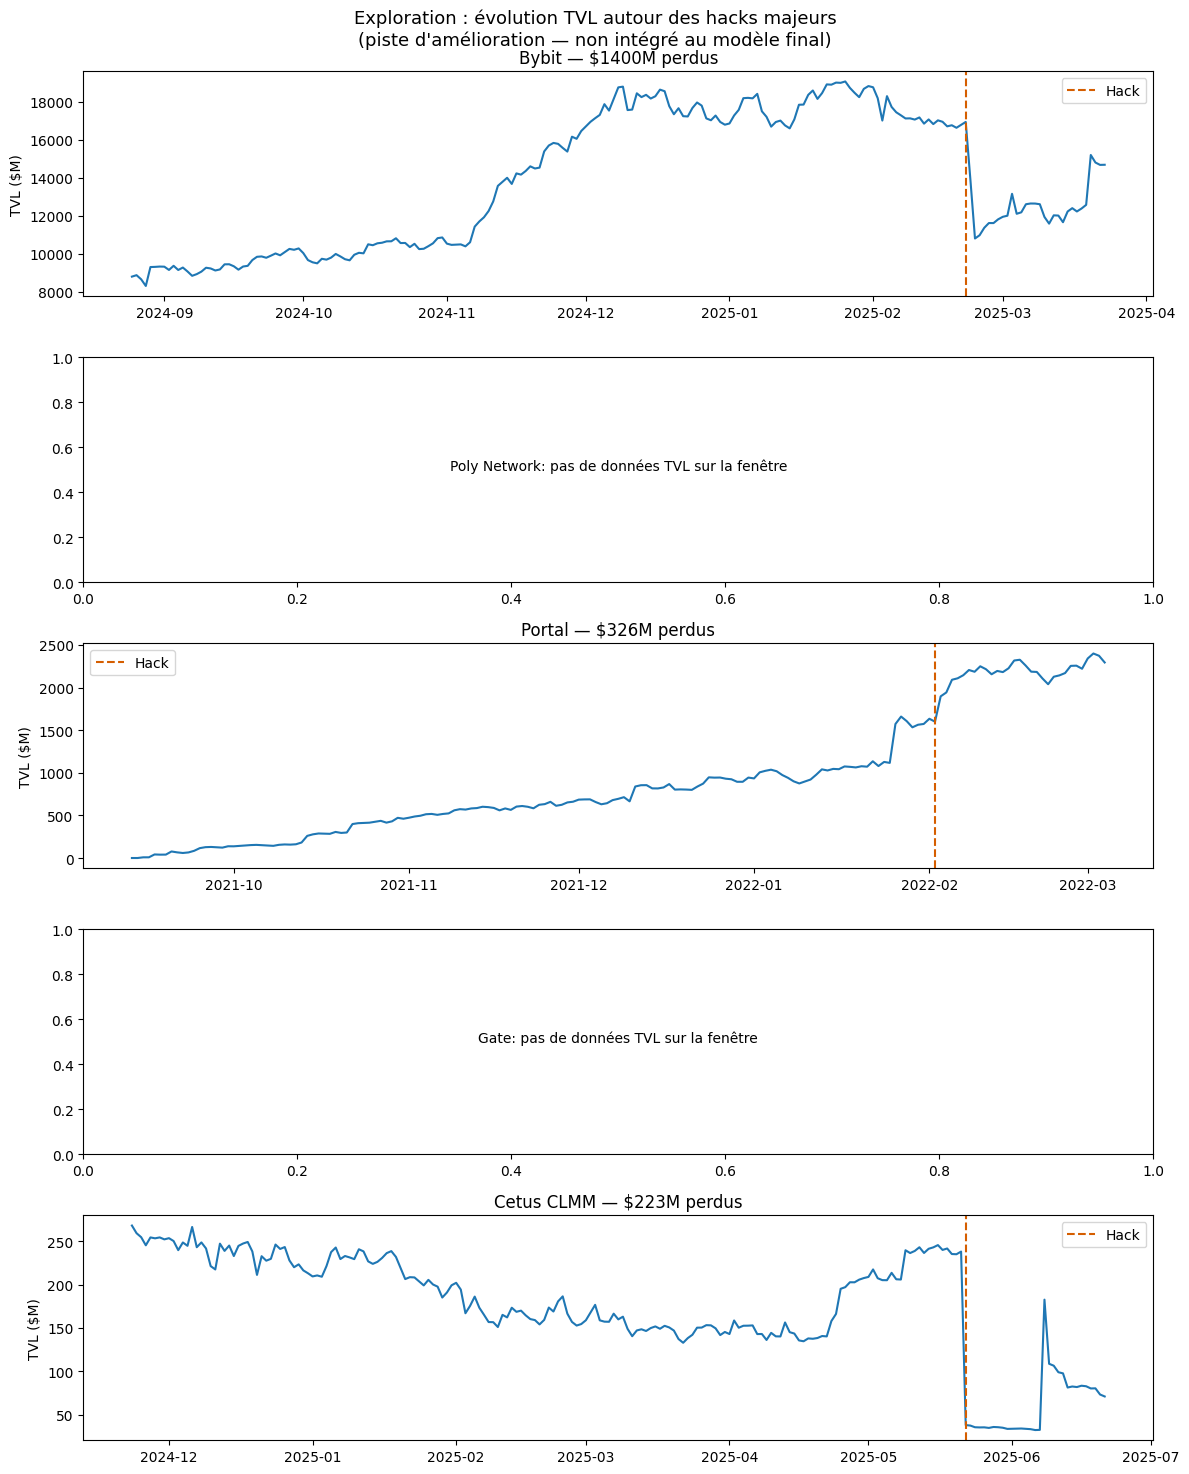

Cette exploration montre que le TVL pré-hack est une feature temporellement
propre pour les protocoles hackés. Pour l'intégrer au modèle, il faudrait
définir une date d'observation équivalente pour les non-hackés (fenêtre glissante).


In [ ]:
# ══════════════════════════════════════════════════════════════
# EXPLORATION : TVL historique pré-hack (piste d'amélioration)
# ══════════════════════════════════════════════════════════════
# L'API DefiLlama /protocol/{slug} fournit l'historique TVL journalier.
# On illustre ici sur quelques protocoles hackés comment le TVL évoluait
# avant l'incident => une feature temporellement propre pour un futur modèle.
# NON intégré au modèle final : pas de date d'observation équivalente
# pour les protocoles non hackés (biais asymétrique).

# Sélection de 5 protocoles hackés avec les plus grosses pertes
sample_hacked = (
    df_merged[df_merged['hacked'] == 1]
    .nlargest(5, 'loss_usd')[['protocol', 'hack_date', 'loss_usd']]
)

fig, axes = plt.subplots(len(sample_hacked), 1, figsize=(12, 3 * len(sample_hacked)))
if len(sample_hacked) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_hacked.iterrows()):
    slug = row['protocol'].lower().replace(' ', '-')
    try:
        resp = requests.get(f'https://api.llama.fi/protocol/{slug}', timeout=10)
        if resp.status_code == 200:
            tvl_data = resp.json().get('tvl', [])
            if tvl_data:
                df_tvl = pd.DataFrame(tvl_data)
                df_tvl['date'] = pd.to_datetime(df_tvl['date'], unit='s')
                df_tvl = df_tvl.set_index('date').sort_index()

                hack_dt = pd.to_datetime(row['hack_date'])
                # Fenêtre : 180j avant → 30j après le hack
                window_start = hack_dt - pd.Timedelta(days=180)
                window_end = hack_dt + pd.Timedelta(days=30)
                df_window = df_tvl.loc[window_start:window_end]

                if not df_window.empty:
                    ax.plot(df_window.index, df_window['totalLiquidityUSD'] / 1e6)
                    ax.axvline(hack_dt, color='#D55E00', linestyle='--', label='Hack')
                    ax.set_title(f"{row['protocol']} — ${row['loss_usd']/1e6:.0f}M perdus")
                    ax.set_ylabel('TVL ($M)')
                    ax.legend()
                else:
                    ax.text(0.5, 0.5, f"{row['protocol']}: pas de données TVL sur la fenêtre",
                            transform=ax.transAxes, ha='center')
            else:
                ax.text(0.5, 0.5, f"{row['protocol']}: historique TVL vide",
                        transform=ax.transAxes, ha='center')
        else:
            ax.text(0.5, 0.5, f"{row['protocol']}: API erreur {resp.status_code}",
                    transform=ax.transAxes, ha='center')
    except Exception as e:
        ax.text(0.5, 0.5, f"{row['protocol']}: {e}", transform=ax.transAxes, ha='center')

plt.suptitle('Exploration : évolution TVL autour des hacks majeurs\n'
             "(piste d'amélioration — non intégré au modèle final)", fontsize=13)
plt.tight_layout()
plt.show()

print('Cette exploration montre que le TVL pré-hack est une feature temporellement')
print("propre pour les protocoles hackés. Pour l'intégrer au modèle, il faudrait")
print("définir une date d'observation équivalente pour les non-hackés (fenêtre glissante).")

In [39]:
# Export Parquet
output_path = f'{DATA_DIR}/df_defi_risk.parquet'
df_final.to_parquet(output_path, index=False, engine='pyarrow')

df_check = pd.read_parquet(output_path)
print(f'✅ Fichier exporté : {output_path}')
print(f'   Taille sur disque : {os.path.getsize(output_path) / 1024:.1f} KB')
print(f'   Lignes : {len(df_check)}, Colonnes : {len(df_check.columns)}')
print(f'\nAperçu :')
df_check[['protocol', 'tvl', 'age_days', 'audit_count', 'audit_status', 'hacked']].head(10)


✅ Fichier exporté : data/df_defi_risk.parquet
   Taille sur disque : 232.7 KB
   Lignes : 4883, Colonnes : 19

Aperçu :


,protocol,tvl,age_days,audit_count,audit_status,hacked
0,Binance CEX,"157,300,895,087.81","1,221.00",0,Unaudited,0
1,Aave V3,"26,226,310,322.40","1,446.00",1,Audited,1
2,OKX,"18,899,856,856.67","1,221.00",0,Unaudited,0
3,Bitfinex,"17,577,249,303.01","1,221.00",0,Unaudited,0
4,Bybit,"16,323,251,209.77","1,217.00",0,Unaudited,1
5,EigenCloud,"10,143,844,705.01","1,006.00",1,Audited,0
6,Binance staked ETH,"8,512,464,517.23","1,052.00",1,Audited,0
7,Morpho V1,"6,995,694,082.59",792.00,1,Audited,0
8,ether.fi Stake,"6,089,052,667.40","1,110.00",0,Unaudited,0
9,Ethena USDe,"5,919,435,225.44",760.00,1,Audited,0


---
## Résumé

| Source | Ce qu'elle apporte | Features produites |
|--------|-------------------|--------------------|
| **DefiLlama `/hacks`** | Labels `hacked=1`, technique, montant, type de cible | `technique`, `loss_usd`, `bridgeHack`, `targetType` |
| **DefiLlama `/protocols`** | Métadonnées des protocoles encore actifs à l'extraction (`TVL > 0`, date valide) | `tvl`, `log_tvl`, `age_days`, `tvl_per_day`, `audit_count`, `chain_count`, `has_audit`, `is_multichain`, `is_dex`, `is_lending`, `is_bridge`, `audit_status` |
| **Rekt News leaderboard** | Enrichissement tenté (0/286 tags exploitables) | *(aucune feature ML)* |

> **Framing important** : le dataset final couvre les protocoles DefiLlama encore actifs (`TVL > 0`, date valide). Les `164` labels positifs modélisés sont donc un sous-ensemble des `472` hacks documentés dans `/hacks`.
>
> **Note** : Dune Analytics a été exploré comme source d'enrichissement on-chain mais n'a pas été retenu : couverture insuffisante sur le périmètre multi-protocoles, matching fragile avec DefiLlama et ne résout pas le risque de biais temporel.

**Passer au Notebook 2** pour entraîner le modèle.
